#### Tissera Ana Paula - `Notebook TP3`

In [1]:
%load_ext autoreload
%autoreload 2

##### Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os
import itertools
import copy


In [3]:
SEED = 42

### `1.` **Análisis y Preprocesamiento de Datos**

In [4]:
X_images = np.load("data/X_images.npy")
y_images = np.load("data/y_images.npy")


In [5]:
print("Forma de X:", X_images.shape)
print("Forma de y:", y_images.shape)
print("Etiquetas únicas:", np.unique(y_images))

Forma de X: (5000, 784)
Forma de y: (5000,)
Etiquetas únicas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]


### Visualización de imágenes

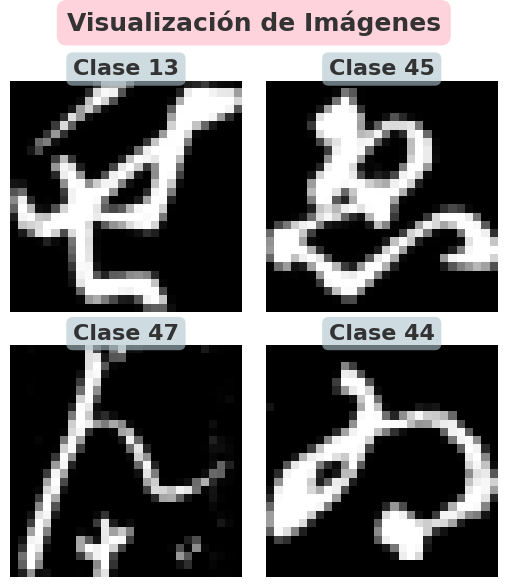

In [6]:
from src.plot import plot_images

name_map = {i: f"Clase {i}" for i in np.unique(y_images)}

# # Llamada al plot
# plot_images(
#     X_images, y_images,
#     indices=list(range(8)),       # muestra las primeras 12
#     n_cols=4,                      # 4 columnas → 3 filas
#     cmap='gray',
#     figsize_scale=2.5,
#     title_bg_color='#AEDFF7',      
#     title_color='#333333',
#     title_alpha=0.6,
#     suptitle="Ejemplo de Imágenes",
#     suptitle_bg='#FCC9B9',         
#     suptitle_color='#333333',
#     suptitle_alpha=0.6,
#     name_map=name_map
# )

np.random.seed(SEED)
clases = np.unique(y_images)
clases_seleccion = np.random.choice(clases, size=4, replace=False)
indices = []
for cl in clases_seleccion:
    idxs_cl = np.where(y_images == cl)[0]
    indices.append(int(np.random.choice(idxs_cl)))

name_map = {i: f"Clase {i}" for i in np.unique(y_images)}

plot_images(
    X_images, y_images,
    indices=indices,         
    n_cols=2,               # número de imágenes     
    suptitle="Visualización de Imágenes",
    name_map=name_map,
    random_seed=SEED
)

In [7]:
print("▶ X:", type(X_images), "shape =", X_images.shape, "dtype =", X_images.dtype)
print("▶ y:", type(y_images), "shape =", y_images.shape, "dtype =", y_images.dtype)

# Si X está aplanado, chequeá min/max
print("▶ X min/max:", X_images.min(), "/", X_images.max())

▶ X: <class 'numpy.ndarray'> shape = (5000, 784) dtype = float32
▶ y: <class 'numpy.ndarray'> shape = (5000,) dtype = int64
▶ X min/max: 0.0 / 255.0


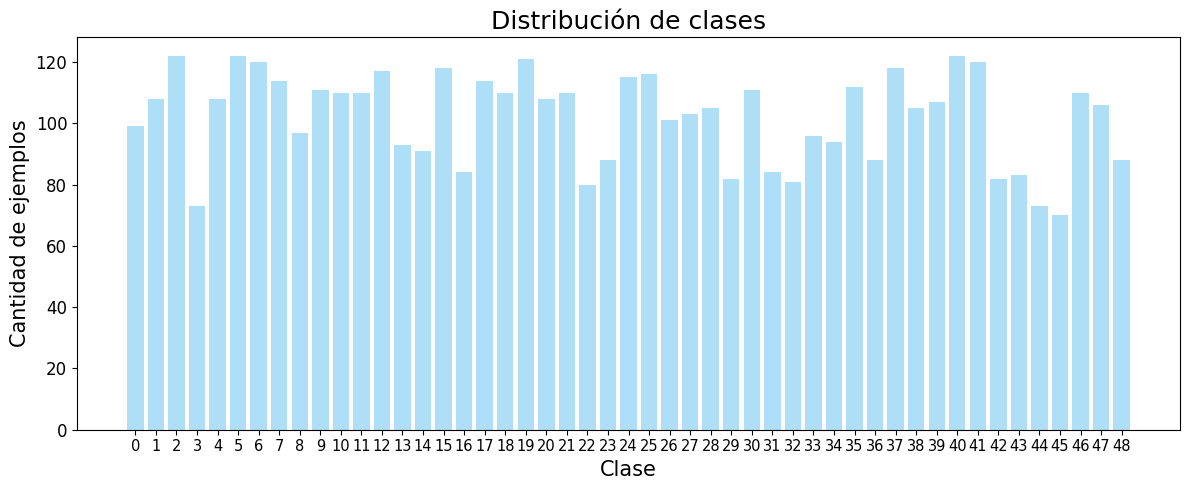

In [8]:
from src.plot import plot_class_distribution
plot_class_distribution(y_images, name_map=name_map, figsize=(12, 5), color='#AEDFF7')

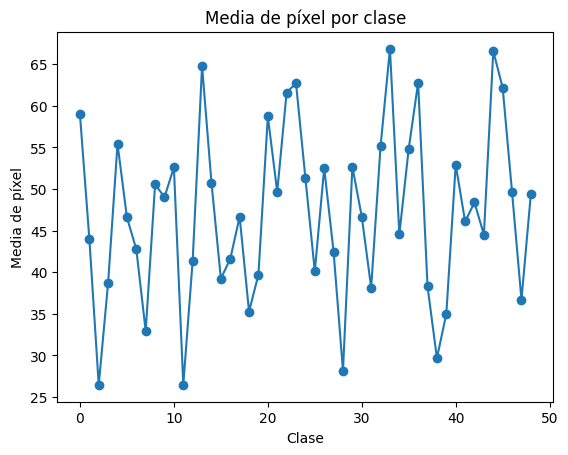

In [9]:
medias = [X_images[y_images==cl].mean() for cl in clases]
plt.plot(clases, medias, marker='o')
plt.xlabel("Clase")
plt.ylabel("Media de píxel")
plt.title("Media de píxel por clase")
plt.show()

In [10]:
print("Media de píxeles en todo X:", X_images.mean())
print("Desviación estándar de píxeles:", X_images.std())

Media de píxeles en todo X: 46.525486
Desviación estándar de píxeles: 87.565414


#### División del dataset


In [35]:
from src.data_splitting import split_data, data_splitter

# X_train, y_train, X_val, y_val, X_test, y_test = data_splitter(X_images, y_images, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42)

X_dev, y_dev, X_test, y_test = split_data(X_images, y_images, ratio=0.2, seed=SEED)

X_train, y_train, X_val, y_val = split_data(X_dev, y_dev, ratio=0.2, seed=SEED)



#### Normalización

In [ ]:
X_train = X_train.astype(np.float32) / 255.0
X_val   = X_val.astype(np.float32)   / 255.0
X_test  = X_test.astype(np.float32)  / 255.0
X_dev   = X_dev.astype(np.float32)   / 255.0

# out_dir = "data/processed"
# os.makedirs(out_dir, exist_ok=True)

# np.savez_compressed(os.path.join(out_dir, "train.npz"), X=X_train, y=y_train)
# np.savez_compressed(os.path.join(out_dir, "val.npz"),   X=X_val,   y=y_val)
# np.savez_compressed(os.path.join(out_dir, "test.npz"),  X=X_test,  y=y_test)

### `2.` **Implementación y Entrenamiento de una Red Neuronal Básica**

red neuronal con 2 capas ocultas, con 100 y 80 nodos

In [26]:
from src.drafts import NeuralNetwork

Training: 100%|██████████| 1000/1000 [01:10<00:00, 14.27it/s, loss=0.203, val_loss=1.88]


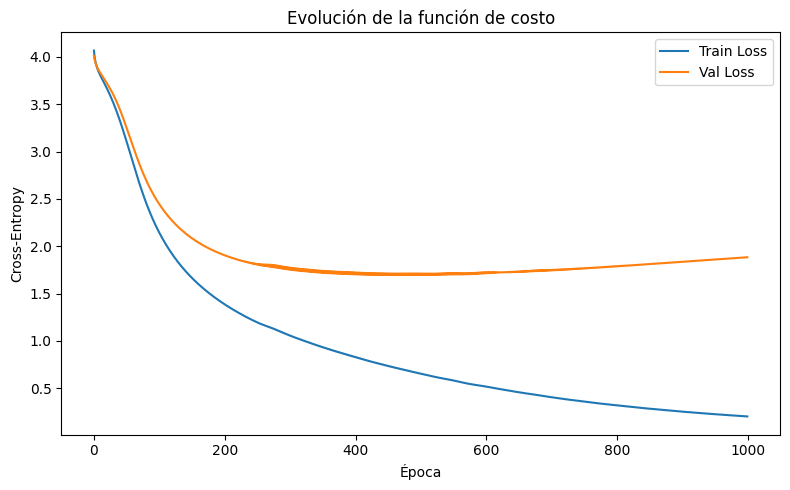

Train accuracy: 97.74%
 Val  accuracy: 59.60%


In [34]:
hidden1, hidden2 = 100, 80
epochs = 1000
lr     = 0.1
SEED   = 42

# One-hot encoding (si aún no lo hiciste)
n_classes  = int(np.max(y_train)) + 1
Y_train_oh = np.eye(n_classes)[y_train]
Y_val_oh   = np.eye(n_classes)[y_val]

# ------- Crear y entrenar la red -------
M0 = NeuralNetwork(
    hidden_layers=[hidden1, hidden2],
    seed=SEED
)

train_losses, val_losses = M0.fit(
    X_train,     y=Y_train_oh,
    X_val=X_val, y_val=Y_val_oh,
    epochs=epochs,
    lr=lr,
    verbose=True
)

# ------- Graficar evolución del loss -------
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Cross‐Entropy")
plt.title("Evolución de la función de costo")
plt.legend()
plt.tight_layout()
plt.show()

# ------- (Opcional) Accuracy -------
y_pred_train = M0.predict(X_train)
train_acc = np.mean(y_pred_train == y_train)
y_pred_val   = M0.predict(X_val)
val_acc   = np.mean(y_pred_val   == y_val)
print(f"Train accuracy: {train_acc*100:.2f}%")
print(f" Val  accuracy: {val_acc*100:.2f}%")

### Métricas en Conjunto de Entrenamiento
**Accuracy:** 0.2150  
**Cross-Entropy Loss:** 3.3754  


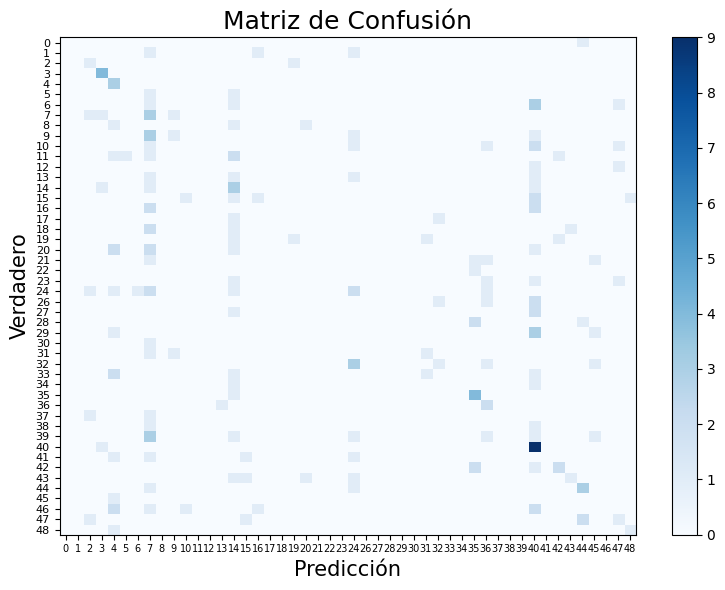

### Métricas en Conjunto de Validación
**Accuracy:** 0.0475  
**Cross-Entropy Loss:** 3.9458  


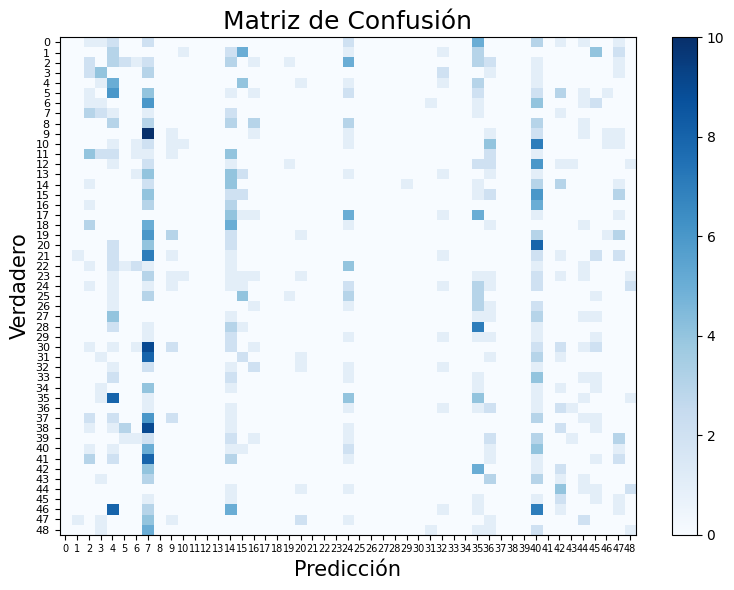

In [28]:

from src.metrics import Metrics  # importa la clase que guardaste en metrics.py

# 1) Calcula predicciones “duro” (etiquetas) y predicciones “blando” (probabilidades)

Y_hat_train = M0.forward(X_train)      # shape (n_classes, m_train)
y_proba_train = Y_hat_train.T          # shape (m_train, n_classes)
y_pred_train  = np.argmax(Y_hat_train, axis=0)  # shape (m_train,)

#    – Para validación:
Y_hat_val   = M0.forward(X_val)        # shape (n_classes, m_val)
y_proba_val = Y_hat_val.T              # shape (m_val, n_classes)
y_pred_val  = np.argmax(Y_hat_val, axis=0)      # shape (m_val,)

# 2) Crea y muestra las métricas con la clase Metrics
#    Puedes pasarle también la lista de labels si quieres un orden específico;
#    si no, los infiere de y_true/y_pred.

# Métricas en entrenamiento
met_train = Metrics(
    y_true=y_train,
    y_pred=y_pred_train,
    y_proba=y_proba_train
)
met_train.report_metrics(title="Métricas en Conjunto de Entrenamiento", show_matrix_table = False, plot_matrix_heatmap= True)

# Métricas en validación
met_val = Metrics(
    y_true=y_val,
    y_pred=y_pred_val,
    y_proba=y_proba_val
)
met_val.report_metrics(title="Métricas en Conjunto de Validación")


### `3.` **Implementación y Entrenamiento de una Red Neuronal Avanzada**

In [283]:
from src.Neural_Network import NeuralNetwork

In [ ]:

configs = {
    'Batch GD':               {'optimizer':'gd'},
    'Rate Scheduling Lineal': {'lr_schedule': 'linear', 'learning_rate':0.2},
    'Rate Scheduling Exp':    {'lr_schedule': 'exp', 'learning_rate':0.45},
    'Stochastic GD':          {'optimizer':'sgd', 'learning_rate':0.01},
    'Mini-batch GD':          {'optimizer':'mb', 'batch_size':32},
    # Mini-batch stochastic gradient descent?
    'Adam':                   {'optimizer':'adam', 'learning_rate':0.01},
    'L2 (λ=1e-3)':            {'l2_lambda':1e-3},
    'EarlyStop (p=5)':        {'early_stopping':True,'patience':5},
    'Dropout (p=0.2)':        {'dropout_p':0.2},
    'BatchNorm':              {'use_batchnorm':True},
}

results = []

for name, params in configs.items():
 
    M0 = NeuralNetwork(
        layer_sizes=[input_size, hidden1, hidden2, n_classes],
        learning_rate=params.get('learning_rate', 0.1),
        seed=SEED,
        optimizer=params.get('optimizer', 'gd'),
        batch_size=params.get('batch_size', None),
        l2_lambda=params.get('l2_lambda', 0.0),
        dropout_p=params.get('dropout_p', 0.0),
        use_batchnorm=params.get('use_batchnorm', False),
        early_stopping=params.get('early_stopping', False),
        patience=params.get('patience', 5),
    )
    
    # definir scheduler
    lr_schedule = None
    if params.get('lr_schedule') == 'linear':
        lr_schedule = M0.get_linear_schedule(final_lr=0.001, max_epochs=epochs)
    elif params.get('lr_schedule') == 'exp':
        lr_schedule = M0.get_exponential_schedule(decay_rate=0.05)
        
    # entrenar
    M0.train_bp(
        X_train, Y_train_oh,
        X_val=X_val, Y_val=Y_val_oh,
        epochs=epochs,
        plot=False,
        lr_schedule=lr_schedule
    )
    
    # 3) Calcular métricas
    # train
    Yhat_tr = M0.forward(X_train, train=False)
    yproba_tr = Yhat_tr.T
    ypred_tr  = np.argmax(Yhat_tr, axis=0)
    m_tr = Metrics(y_true=y_train, y_pred=ypred_tr, y_proba=yproba_tr)
    acc_tr = m_tr.accuracy()
    ce_tr  = m_tr.cross_entropy()
    # val
    Yhat_v = M0.forward(X_val, train=False)
    yproba_v = Yhat_v.T
    ypred_v  = np.argmax(Yhat_v, axis=0)
    m_v = Metrics(y_true=y_val, y_pred=ypred_v, y_proba=yproba_v)
    acc_v = m_v.accuracy()
    ce_v  = m_v.cross_entropy()

    results.append((name, acc_tr, ce_tr, acc_v, ce_v))

# 4) Montar la tabla Markdown
header = "|Método|Acc Train|CE Loss Train|Acc Val|CE Loss Val|\n"
sep    = "|" + "---|"*5 + "\n"
rows   = ""
for name, at, ct, av, cv in results:
    rows += f"|{name}|{at:.4f}|{ct:.4f}|{av:.4f}|{cv:.4f}|\n"

table_md = header + sep + rows

# 5) Mostrar
display(Markdown("## Comparativa de Métricas"))
display(Markdown(table_md))

Early stopping en época 82


## Comparativa de Métricas

|Método|Acc Train|CE Loss Train|Acc Val|CE Loss Val|
|---|---|---|---|---|
|Batch GD|0.9950|0.2576|0.2362|3.5380|
|Rate Scheduling Linear|0.9950|0.2552|0.2338|3.5429|
|Rate Scheduling  Exp|0.9950|0.3414|0.2213|3.5108|
|Stochastic GD|1.0000|0.0018|0.2712|4.7937|
|Mini-batch GD|1.0000|0.0068|0.2600|4.3252|
|Adam|1.0000|0.0000|0.2838|9.7248|
|L2 (λ=1e-3)|0.9950|0.2576|0.2362|3.5380|
|EarlyStop (p=5)|0.9900|0.4145|0.2150|3.5101|
|Dropout (p=0.2)|0.9800|0.4752|0.2313|3.4057|
|BatchNorm|1.0000|0.0053|0.1150|6.2504|


In [42]:
import time

In [46]:
architectures = [
    # Redes ligeras (rápidas de entrenar, menos parámetros)
    [input_size, 32, n_classes],
    [input_size, 64, n_classes],
    [input_size, 64, 32, n_classes],
    
    # Redes de complejidad media (equilibrio)
    [input_size, 100, n_classes],
    [input_size, 128, 64, n_classes],
    [input_size, 100, 50, n_classes],
    [input_size, 64, 64, 32, n_classes],
    
    # Redes más profundas (más capacidad, más lentas)
    [input_size, 150, 80, n_classes],
    [input_size, 128, 64, 32, n_classes],
    [input_size, 256, 128, 64, n_classes],

    # Arquitecturas alternativas con tres capas ocultas
    [input_size, 100, 50, 25, n_classes],
    [input_size, 128, 128, 64, 32, n_classes],
]

param_grid = {
    'arch':           architectures,
    'optimizer':      ['gd','sgd','mb','adam'],
    'learning_rate':  [0.001, 0.01, 0.05, 0.1, 0.2],
    'batch_size':     [None, 16, 32, 64, 128, 256],        # solo si optimizer='mb'
    'l2_lambda':      [0.0, 1e-3, 1e-2, 1e-1, 1],
    'dropout_p':      [0.0, 0.15, 0.2, 0.25],
    'use_batchnorm':  [False, True],
    'early_stopping': [False, True],
    'patience':       [5, 10, 20, 50],               # solo si early_stopping=True
    'lr_schedule':    ['none','linear','exp'],
}

# 2) Función para evaluar una configuración con pocas épocas

def evaluate_config(cfg):
    nn = NeuralNetwork(
        layer_sizes=cfg['arch'],
        learning_rate=cfg['learning_rate'],
        seed=SEED,
        optimizer=cfg['optimizer'],
        batch_size=cfg['batch_size'],
        l2_lambda=cfg['l2_lambda'],
        dropout_p=cfg['dropout_p'],
        use_batchnorm=cfg['use_batchnorm'],
        early_stopping=False,
        patience=0
    )
    # Scheduler
    if cfg['lr_schedule'] == 'linear':
        sched = nn.get_linear_schedule(final_lr=0.001, max_epochs=5)
    elif cfg['lr_schedule'] == 'exp':
        sched = nn.get_exponential_schedule(decay_rate=0.1)
    else:
        sched = None

    nn.train_bp(
        X_train, Y_train_oh,
        X_val=X_val, Y_val=Y_val_oh,
        epochs=1000,
        plot=False,
        lr_schedule=sched
    )
    Yh = nn.forward(X_val, train=False)
    met = Metrics(
        y_true=y_val,
        y_pred=np.argmax(Yh,axis=0),
        y_proba=Yh.T
    )
    return met.cross_entropy()

def greedy_hypersearch(param_grid, initial_cfg, rounds=3):
    best_cfg = copy.deepcopy(initial_cfg)
    best_score = evaluate_config(best_cfg)

    for r in range(rounds):
        round_start = time.time()
        print(f"\n-- Ronda {r+1}, CE actual = {best_score:.4f} --")
        improved = False

        for param, values in param_grid.items():
            for v in values:
                # filtros
                if param == 'batch_size' and best_cfg['optimizer'] != 'mb' and v is not None:
                    continue
                if param == 'patience' and not best_cfg['early_stopping']:
                    continue
                if best_cfg[param] == v:
                    continue

                cfg = copy.deepcopy(best_cfg)
                cfg[param] = v

                test_start = time.time()
                try:
                    score = evaluate_config(cfg)
                except Exception as e:
                    print(f"  !! error {param}={v}: {e}")
                    continue
                test_end = time.time()

                print(f"  Probando {param}={v} → CE={score:.4f} "
                      f"({test_end-test_start:.1f}s)")

                if score < best_score:
                    print(f"   ✅ Mejora: {param} pasa de {best_cfg[param]} a {v}")
                    best_score = score
                    best_cfg = cfg
                    improved = True

        round_end = time.time()
        print(f"Ronda {r+1} completada en {(round_end-round_start):.1f}s\n")
        if not improved:
            print("No hubo mejoras en esta ronda. Fin.")
            break

    return best_cfg, best_score

# --- Ejecución ---
# 4) Configuración inicial
initial_cfg = {
    'arch':           architectures[0],
    'optimizer':      'gd',
    'learning_rate':  0.01,
    'batch_size':     None,
    'l2_lambda':      0.0,
    'dropout_p':      0.0,
    'use_batchnorm':  False,
    'early_stopping': False,
    'patience':       5,
    'lr_schedule':    'none',
}

best_cfg, best_score = greedy_hypersearch(param_grid, initial_cfg, rounds=5)

print("\n👉 Mejor configuración encontrada:")
for k, v in best_cfg.items():
    print(f"   {k}: {v}")
print(f"CE en validación = {best_score:.4f}")


-- Ronda 1, CE actual = 3.6520 --
  Probando arch=[784, 64, 49] → CE=3.3096 (10.4s)
   ✅ Mejora: arch pasa de [784, 32, 49] a [784, 64, 49]
  Probando arch=[784, 64, 32, 49] → CE=3.8843 (10.4s)
  Probando arch=[784, 100, 49] → CE=3.2717 (9.6s)
   ✅ Mejora: arch pasa de [784, 64, 49] a [784, 100, 49]
  Probando arch=[784, 128, 64, 49] → CE=3.4175 (11.5s)
  Probando arch=[784, 100, 50, 49] → CE=3.4479 (11.4s)
  Probando arch=[784, 64, 64, 32, 49] → CE=4.4527 (12.0s)
  Probando arch=[784, 150, 80, 49] → CE=3.3692 (13.4s)
  Probando arch=[784, 128, 64, 32, 49] → CE=4.0990 (15.5s)
  Probando arch=[784, 256, 128, 64, 49] → CE=3.8096 (19.8s)
  Probando arch=[784, 100, 50, 25, 49] → CE=4.5027 (13.3s)
  Probando arch=[784, 128, 128, 64, 32, 49] → CE=4.7145 (18.1s)


KeyboardInterrupt: 